## Установка и импорт библиотек

In [ ]:
!pip install nltk pymorphy3 gensim fasttext razdel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 38.6 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

import nltk
import pymorphy3
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import re
from wordcloud import WordCloud

from razdel import tokenize
import fasttext
import fasttext.util

from datasets import load_dataset
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

from collections import Counter

from gensim.models import Word2Vec, FastText

from tqdm.notebook import tqdm

import warnings
warnings.filterwarnings('ignore')

In [ ]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

## Загрузка датасета и его обзор

In [ ]:
train_dataset = load_dataset("d0rj/rudetoxifier_data", split="train")
test_dataset = load_dataset("d0rj/rudetoxifier_data", split="test")

README.md:   0%|          | 0.00/989 [00:00<?, ?B/s]

data/train-00000-of-00001-44684fb552b9d8(…):   0%|          | 0.00/15.4M [00:00<?, ?B/s]

data/test-00000-of-00001-3fa069f4ebce7d2(…):   0%|          | 0.00/984k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/163187 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

In [ ]:
train = train_dataset.to_pandas()
test = test_dataset.to_pandas()

In [ ]:
print(train.shape)
print(test.shape)

(163187, 2)
(10000, 2)


In [ ]:
train.head(5)

,text,toxic
0,дворника надо тоже уничтожить!,1.0
1,"моя старшая неделю шипела, не принимала подкид...",0.0
2,полностью с вами согласна!,0.0
3,"хоть ногу вверх, ничего не изменится",0.0
4,а что значит - левого ребенка?,0.0


In [ ]:
test.head(5)

,text,toxic
0,долбоебы не иначе,1.0
1,Вечная память героям! Вас будут помнить и чере...,1.0
2,выебать его и его ночяльника и кинуть его жопу...,1.0
3,такую надо ебать,1.0
4,долбоеб старый в хоч импо тент но полиз понюх ...,1.0


In [ ]:
train.dtypes

,0
text,object
toxic,float64


In [ ]:
train['toxic'] = train['toxic'].astype(int)
train['toxic'] = train['toxic'].astype(int)

##EDA

###Облако слов

In [ ]:
stop_words = stopwords.words("russian")

def plot_wordcloud(comment, title):
    wordcloud = WordCloud(width=800, height=800, background_color='white', stopwords=stop_words,
                          min_font_size=10).generate(comment)
    plt.figure(figsize=(14, 6), facecolor=None)
    plt.imshow(wordcloud)
    plt.axis("off")
    plt.title(title, fontdict={'fontsize': 20})
    plt.show()

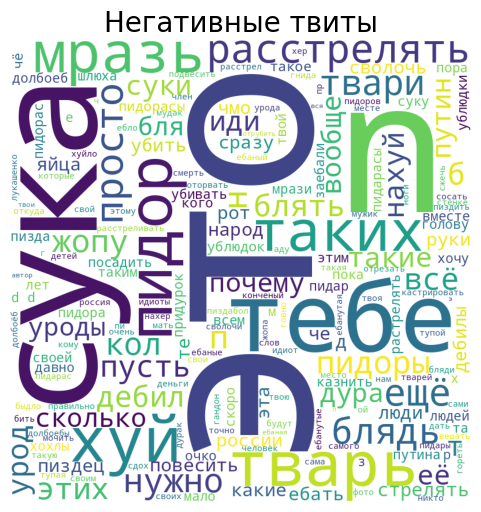

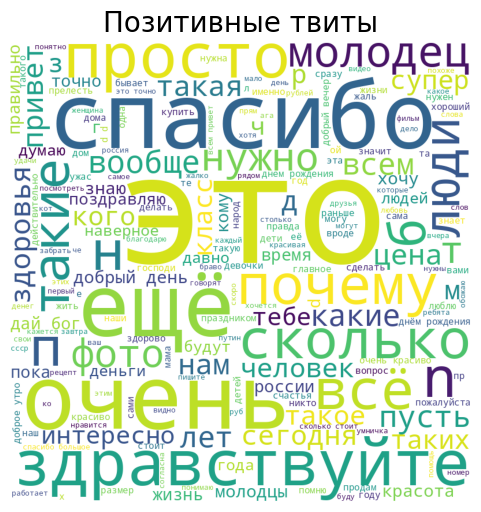

In [ ]:
negative_tweets = train['text'][train['toxic'] == 1].to_string()
positive_tweets = train['text'][train['toxic'] == 0].to_string()

plot_wordcloud(negative_tweets, 'Негативные твиты')
plot_wordcloud(positive_tweets, 'Позитивные твиты')

###Изучим данные

In [ ]:
train_eda = train.copy()
train_eda['comment_length'] = train_eda['text'].str.len()
train_eda['num_voskl'] = train_eda['text'].str.count('!')
train_eda['num_vopros'] = train_eda['text'].str.count('\?')
train_eda['num_punctuations'] = train_eda['text'].str.count('[.,:;]')
train_eda['num_words'] = train_eda['text'].apply(lambda x: len(x.split()))
train_eda.head()

,text,toxic,comment_length,num_voskl,num_vopros,num_punctuations,num_words
0,дворника надо тоже уничтожить!,1,30,1,0,0,4
1,"моя старшая неделю шипела, не принимала подкид...",0,195,0,0,8,28
2,полностью с вами согласна!,0,26,1,0,0,4
3,"хоть ногу вверх, ничего не изменится",0,36,0,0,1,6
4,а что значит - левого ребенка?,0,30,0,1,0,6


In [ ]:
train_eda['num_words'].max()

1078

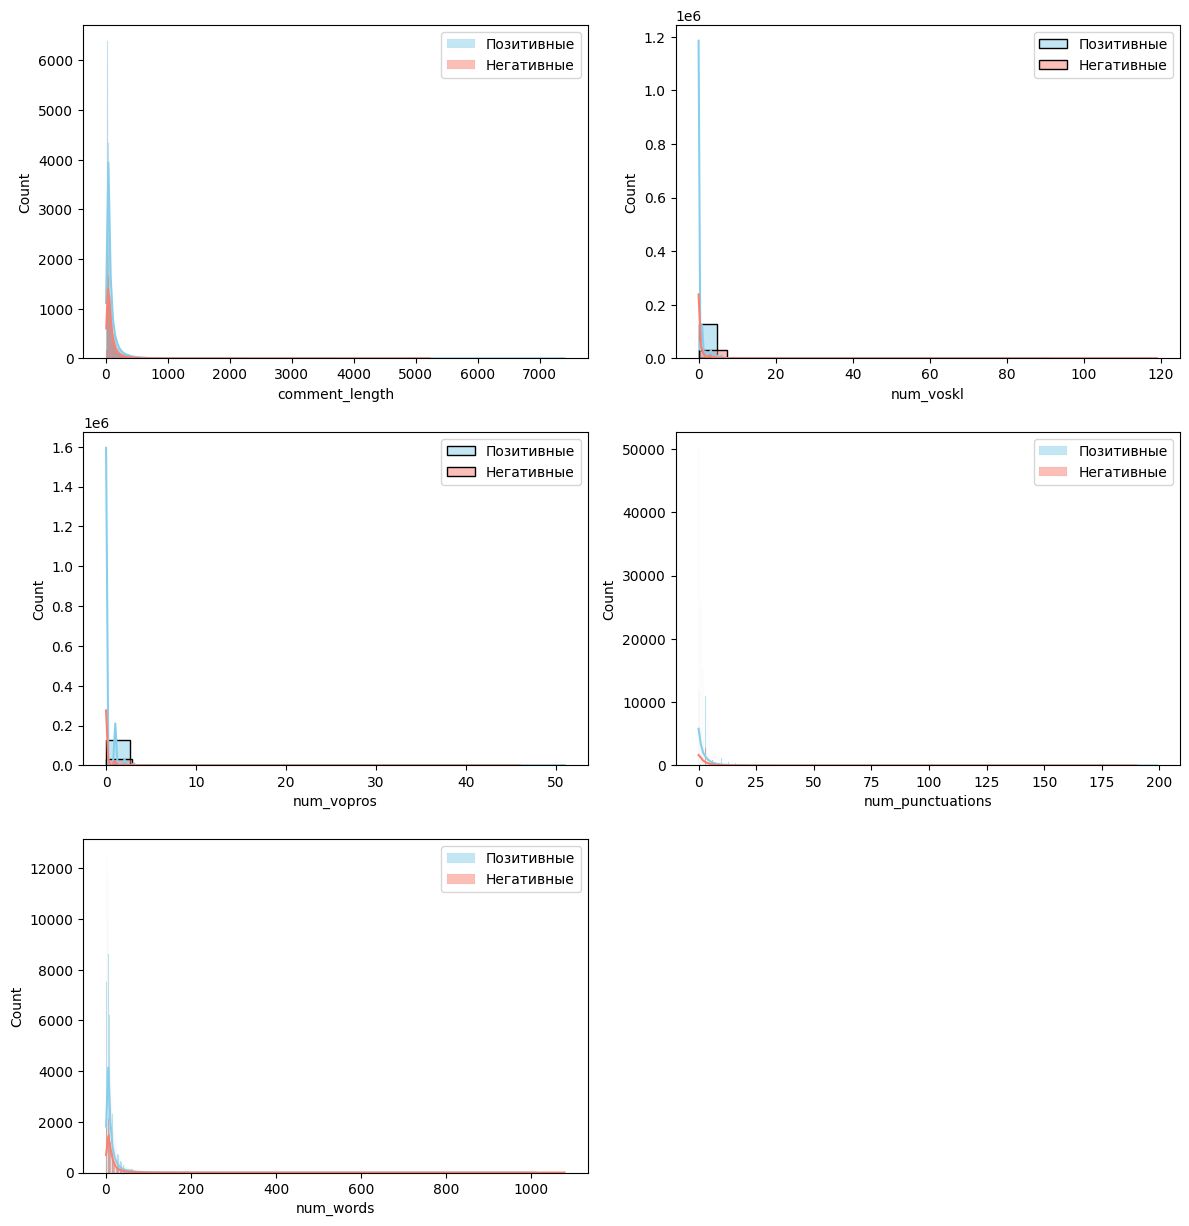

In [ ]:
features = ['comment_length', 'num_voskl', 'num_vopros',
            'num_punctuations', 'num_words']

if set(features).issubset(train_eda.columns):
    plt.figure(figsize=(12, 16))
    colors = ['skyblue', 'salmon']

    for i, feature in enumerate(features, 1):
        plt.subplot(4, 2, i)
        sns.histplot(train_eda[train_eda.toxic == 0][feature], label='Позитивные', kde=True, color=colors[0])
        sns.histplot(train_eda[train_eda.toxic == 1][feature], label='Негативные', kde=True, color=colors[1])
        plt.legend()

    plt.tight_layout()
    plt.show()

## Предобработка

In [ ]:
train_copy = train.copy()
test_copy = test.copy()

In [ ]:
morph = pymorphy3.MorphAnalyzer()

In [ ]:
def preprocess_text(text):
    pattern = re.compile(r'[a-zA-Zа-яА-Я]+', re.UNICODE)
    words = re.findall(pattern, text)

    words = word_tokenize(' '.join(words), language='russian')
    filtered_words = [word for word in words if word.lower() not in stop_words]

    lemmatized_words = [morph.parse(word)[0].normal_form for word in filtered_words]

    return ' '.join(lemmatized_words)

In [ ]:
train_copy['text'] = train_copy['text'].apply(preprocess_text)

In [ ]:
train_copy.head(15)

,text,toxic
0,дворник уничтожить,1
1,старший неделя шипеть принимать подкидыш котор...,0
2,полностью вы согласный,0
3,нога вверх измениться,0
4,значит левый ребёнок,0
5,вечер добрый постарелый,0
6,порода,0
7,спасатель просто петух чванливый взять наш пац...,1
8,замечательный юбилей голос чудо заслушаться чт...,0
9,красавец,0


In [ ]:
test_copy['text'] = test_copy['text'].apply(preprocess_text)

In [ ]:
train_data, val_data = train_test_split(train_copy, test_size=0.10, random_state=42)

In [ ]:
print(train_data.shape)
print(val_data.shape)

(146868, 2)
(16319, 2)


## TF-IDF with Logistic Regression

In [ ]:
X_train = train_data['text']
y_train = train_data['toxic']

X_val = val_data['text']
y_val = val_data['toxic']

In [ ]:
vectorizer = TfidfVectorizer(
        max_features=10000,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True,
        strip_accents='unicode',
        analyzer='word',
        token_pattern=r'\w{2,}',
    )

In [ ]:
X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)

In [ ]:
print(f"TF-IDF matrix: {X_train_tfidf.shape}")
print(f"Sparsity: {1 - X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1]):.3f}")

TF-IDF matrix: (146868, 10000)
Sparsity: 0.999


In [ ]:
classifier = LogisticRegression(
  C=10.0,
  max_iter=1000,
  solver='liblinear',
  multi_class='ovr'
)

In [ ]:
classifier.fit(X_train_tfidf, y_train)

LogisticRegression(C=10.0, max_iter=1000, multi_class='ovr', solver='liblinear')

In [ ]:
y_pred = classifier.predict(X_val_tfidf)

print("Отчет о классификации:\n")
print(classification_report(y_val, y_pred))

Отчет о классификации:

              precision    recall  f1-score   support

           0       0.95      0.99      0.97     13144
           1       0.93      0.79      0.86      3175

    accuracy                           0.95     16319
   macro avg       0.94      0.89      0.91     16319
weighted avg       0.95      0.95      0.95     16319



## LSTM

In [ ]:
def tokenizer(text):
    return [token.text.lower() for token in tokenize(text)]

In [ ]:
counter = Counter()

for text in X_train:
    counter.update(tokenizer(text))

In [ ]:
max_vocab = 30000

most_common = counter.most_common(max_vocab - 2)

vocab = {
    "<pad>": 0,
    "<unk>": 1
}

for word, _ in most_common:
    vocab[word] = len(vocab)

In [ ]:
def encode(text):
    return [
        vocab.get(token, vocab["<unk>"])
        for token in tokenizer(text)
    ]

train_data['tokens'] = train_data['text'].apply(encode)
val_data['tokens'] = val_data['text'].apply(encode)

In [ ]:
class ToxicDataset(Dataset):
    def __init__(self, df):
        self.texts = df["tokens"].tolist()
        self.labels = df["toxic"].astype(int).tolist()

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.texts[idx], dtype=torch.long),
            torch.tensor(self.labels[idx], dtype=torch.float)
        )

In [ ]:
PAD_IDX = vocab["<pad>"]

def collate_fn(batch):
    texts, labels = zip(*batch)

    texts = [torch.tensor(x, dtype=torch.long) for x in texts]

    lengths = torch.tensor([len(x) for x in texts])

    texts = pad_sequence(
        texts,
        batch_first=True,
        padding_value=PAD_IDX
    )

    labels = torch.stack(labels)

    return texts, lengths, labels

In [ ]:
train_dataset = ToxicDataset(train_data)
val_dataset = ToxicDataset(val_data)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    collate_fn=collate_fn
)

In [ ]:
for x, lengths, y in val_loader:
    print(x.shape)       # (batch, seq_len)
    print(lengths[:5])
    print(y[:5])
    break

torch.Size([64, 53])
tensor([ 2,  5,  3, 11,  4])
tensor([0., 0., 1., 0., 0.])


In [ ]:
class ToxicBiLSTM(nn.Module):
    def __init__(self, vocab_size, emb_dim=128, hidden_dim=128, pad_idx=0):
        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            emb_dim,
            padding_idx=pad_idx
        )

        self.lstm = nn.LSTM(
            input_size=emb_dim,
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=True
        )

        self.fc = nn.Linear(hidden_dim * 2, 1)

    def forward(self, x):
        emb = self.embedding(x)

        out, (h, c) = self.lstm(emb)
        h_forward = h[0]
        h_backward = h[1]

        h_cat = torch.cat((h_forward, h_backward), dim=1)

        logits = self.fc(h_cat)

        return logits.squeeze(1)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ToxicBiLSTM(
    vocab_size=len(vocab),
    pad_idx=vocab["<pad>"]
).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
EPOCHS = 10

In [ ]:
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

for epoch in range(EPOCHS):
    model.train()

    train_loss = 0
    train_correct = 0
    train_total = 0

    train_bar = tqdm(train_loader, desc=f'Эпоха {epoch+1}/{EPOCHS} [Train]',
                     leave=False, ncols=100)

    for texts, lengths, labels in train_bar:
        texts = texts.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        logits = model(texts)

        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float()

        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    train_loss = train_loss / len(train_loader)
    train_acc = train_correct / train_total

    model.eval()

    val_loss = 0
    val_correct = 0
    val_total = 0

    val_bar = tqdm(val_loader, desc=f'Эпоха {epoch+1}/{EPOCHS} [Val]',
                   leave=False, ncols=100)

    with torch.no_grad():
      for texts, lengths, labels in val_bar:
          texts = texts.to(device)
          labels = labels.to(device)

          logits = model(texts)

          loss = criterion(logits, labels)
          val_loss += loss.item()

          probs = torch.sigmoid(logits)
          preds = (probs > 0.5).float()

          val_correct += (preds == labels).sum().item()
          val_total += labels.size(0)

    val_loss = val_loss / len(val_loader)
    val_acc = val_correct / val_total

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f'Эпоха {epoch+1:2d}/{EPOCHS} | '
          f'Train Loss: {train_loss:.4f} | '
          f'Train Acc: {train_acc * 100:.2f}% | '
          f'Val Loss: {val_loss:.4f} | '
          f'Val Acc: {val_acc * 100:.2f}%')

Эпоха 1/10 [Train]:   0%|                                                  | 0/2295 [00:00<?, ?it/s]

Эпоха 1/10 [Val]:   0%|                                                     | 0/255 [00:00<?, ?it/s]

Эпоха  1/10 | Train Loss: 0.2328 | Train Acc: 91.30% | Val Loss: 0.1610 | Val Acc: 94.29%


Эпоха 2/10 [Train]:   0%|                                                  | 0/2295 [00:00<?, ?it/s]

Эпоха 2/10 [Val]:   0%|                                                     | 0/255 [00:00<?, ?it/s]

...

Эпоха 9/10 [Val]:   0%|                                                     | 0/255 [00:00<?, ?it/s]

Эпоха  9/10 | Train Loss: 0.0127 | Train Acc: 99.60% | Val Loss: 0.2697 | Val Acc: 94.83%


Эпоха 10/10 [Train]:   0%|                                                 | 0/2295 [00:00<?, ?it/s]

Эпоха 10/10 [Val]:   0%|                                                    | 0/255 [00:00<?, ?it/s]

Эпоха 10/10 | Train Loss: 0.0116 | Train Acc: 99.65% | Val Loss: 0.2861 | Val Acc: 94.49%
